# Laboratorio de regresión - 2

|                |   |
:----------------|---|
| **Nombre**     | Jorge Oviedo Magaña  |
| **Fecha**      |  31/01/2026 |
| **Expediente** |  757048 |

## Regresión polinomial

Observa la siguiente gráfica.

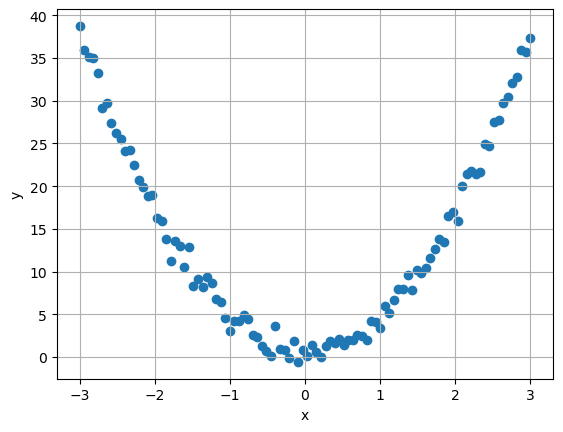

In [57]:
import matplotlib.pyplot as plt; import numpy as np
%matplotlib inline
np.random.seed(0)
x = np.linspace(-3, 3, 100); y = 1 + 4*x**2 + np.random.normal(0, 1, 100)
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y); plt.grid()

Utiliza `sklearn` para realizar una regresión lineal simple ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x $)

In [58]:
#utilizar sklearn para ajustar un modelo de regresión lineal simple (y = a + b*x)
from sklearn.linear_model import LinearRegression
x_reshaped = x.reshape(-1, 1)
model = LinearRegression(); model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)
print(f"Coeficiente: {model.coef_[0]}, Intercepto: {model.intercept_}")




Coeficiente: -0.0495544774359067, Intercepto: 13.30223225795873


Nota: No es demasiado acercado, pero esta dentro del rango

Crea una gráfica donde se muestren las observaciones como una nube de puntos y la línea que ajustaste con regresión. Calcula el métrico $R^2$.

In [59]:
#metrico R2 [coeficiente de determinación(es una medida de qué tan bien se ajusta un modelo a los datos)]
from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred)
print(f"R2: {r2}")


R2: 5.80345273922811e-05


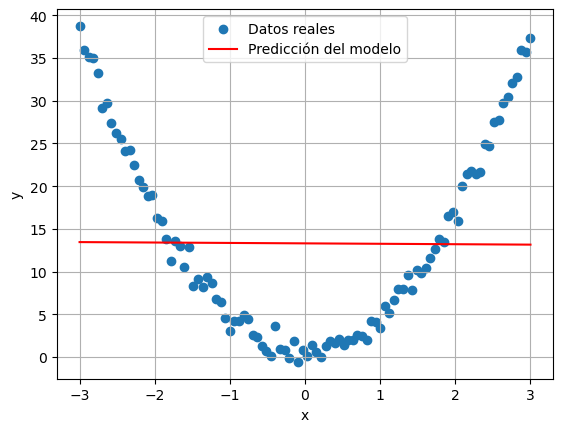

In [60]:
#grafica de las obsevaciones como nube de puntos y la linea que ajuste con la regresion lineal
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y, label="Datos reales"); plt.plot(x, y_pred, color='red', label="Predicción del modelo")
plt.legend(); plt.grid()


Podemos ver que el ajuste no es correcto, pues parece que tiene un comportamiento cuadrático y estamos intentando ajustar una línea recta.

En lugar de hacer una regresión lineal simple, quizás podamos extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X + \beta_2 X^2 + ... + \beta_p X^p + \epsilon$$

Ajusta un modelo cuadrático con `sklearn` ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x + \hat{\beta_1}x^2 $) y calcula su $R^2$.

In [61]:
#modelo cuadratico (y = a + b*x + c*x^2)
from sklearn.preprocessing import PolynomialFeatures
poly2 = PolynomialFeatures(degree=2); x_poly = poly.fit_transform(x_reshaped)
model_poly = LinearRegression(); model_poly.fit(x_poly, y)
y_poly_pred = model_poly.predict(x_poly)
print(f"Coeficientes: {model_poly.coef_}, Intercepto: {model_poly.intercept_}")

Coeficientes: [ 0.         -0.04955448  4.14388884], Intercepto: 0.619420963180481


In [62]:
#R2 para el modelo cuadrático
r2_poly = r2_score(y, y_poly_pred)
print(f"R2 modelo cuadrático: {r2_poly}")


R2 modelo cuadrático: 0.9934118040713642


Crea una gráfica con las observaciones y la nueva curva que ajustaste.

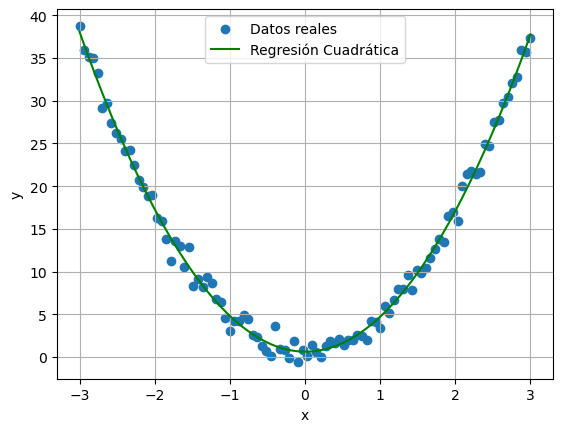

In [63]:
#grafica de comparacion entre los dos modelos
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y, label="Datos reales")
plt.plot(x, y_poly_pred, color='green', label="Regresión Cuadrática")
plt.legend(); plt.grid()

Ajusta modelos de grados 3, 5, 7, 9, y 11. Calcula su $R^2$.

In [64]:
#grado 3 
poly3 = PolynomialFeatures(degree=3); x_poly3 = poly3.fit_transform(x_reshaped)
model_poly3 = LinearRegression(); model_poly3.fit(x_poly3, y)
y_poly3_pred = model_poly3.predict(x_poly3)
r2_poly3 = r2_score(y, y_poly3_pred)
print(f"R2 modelo cúbico: {r2_poly3}")



R2 modelo cúbico: 0.9934129585186598


In [65]:
#grado 5
poly5 = PolynomialFeatures(degree=5); x_poly5 = poly5.fit_transform(x_reshaped)
model_poly5 = LinearRegression(); model_poly5.fit(x_poly5, y)
y_poly5_pred = model_poly5.predict(x_poly5)
r2_poly5 = r2_score(y, y_poly5_pred)
print(f"R2 modelo grado 5: {r2_poly5}")

R2 modelo grado 5: 0.9934954953676421


In [66]:
#grado 7
poly7 = PolynomialFeatures(degree=7); x_poly7 = poly7.fit_transform(x_reshaped)
model_poly7 = LinearRegression(); model_poly7.fit(x_poly7, y)
y_poly7_pred = model_poly7.predict(x_poly7)
r2_poly7 = r2_score(y, y_poly7_pred)
print(f"R2 modelo grado 7: {r2_poly7}")

R2 modelo grado 7: 0.9935089341876935


In [67]:
#grado 9
poly9 = PolynomialFeatures(degree=9); x_poly9 = poly9.fit_transform(x_reshaped)
model_poly9 = LinearRegression(); model_poly9.fit(x_poly9, y)
y_poly9_pred = model_poly9.predict(x_poly9)
r2_poly9 = r2_score(y, y_poly9_pred)
print(f"R2 modelo grado 9: {r2_poly9}")

R2 modelo grado 9: 0.9935141799662259


In [68]:
#grado 11
poly11 = PolynomialFeatures(degree=11); x_poly11 = poly11.fit_transform(x_reshaped)
model_poly11 = LinearRegression(); model_poly11.fit(x_poly11, y)
y_poly11_pred = model_poly11.predict(x_poly11)
r2_poly11 = r2_score(y, y_poly11_pred)
print(f"R2 modelo grado 11: {r2_poly11}")

R2 modelo grado 11: 0.9935338704150221


Crea una gráfica por cada modelo con las observaciones y su curva.

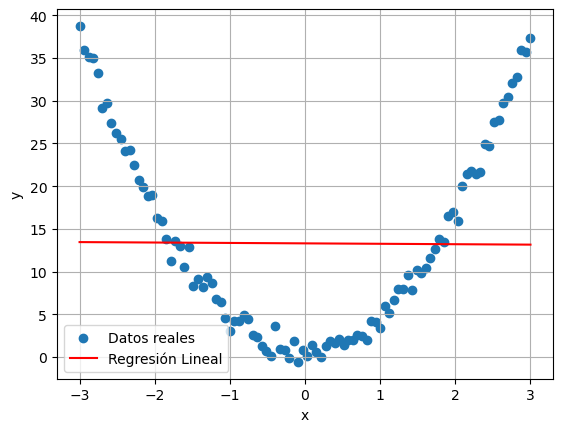

In [69]:
#grafica modelo simple
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y, label="Datos reales"); plt.plot(x, y_pred, color='red', label="Regresión Lineal")
plt.legend(); plt.grid()

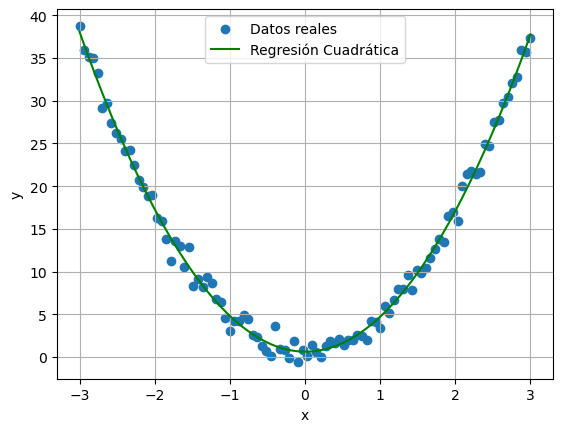

In [70]:
#modelo grado 2
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y, label="Datos reales"); plt.plot(x, y_poly_pred, color='green', label="Regresión Cuadrática")
plt.legend(); plt.grid()


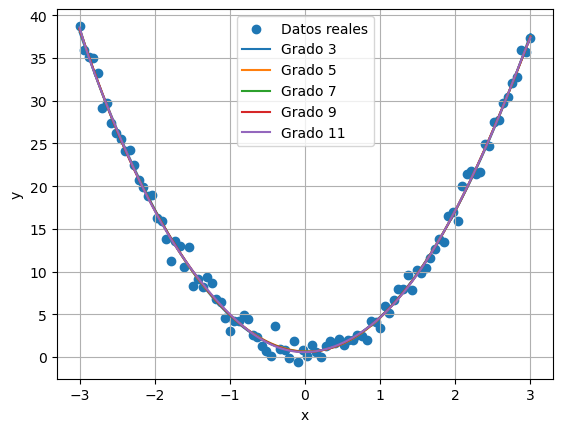

In [71]:
#otros modelos de mayor grado pueden ser probados de manera similar
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y, label="Datos reales")
plt.plot(x, y_poly3_pred, label="Grado 3")
plt.plot(x, y_poly5_pred, label="Grado 5")
plt.plot(x, y_poly7_pred, label="Grado 7")
plt.plot(x, y_poly9_pred, label="Grado 9")
plt.plot(x, y_poly11_pred, label="Grado 11")
plt.legend(); plt.grid()


**¿Cuál modelo consideras que es mejor? ¿Por qué?**

Considero mejor el modelo cuadratico ya que la grafica inicial es muy cercana a una funcion cuadratica, por eso el modelo cuadratico se ajusta muy bien.

Recuerda que una de las metas de ajustar modelos es para poder interpolar y extrapolar. Los datos que tenemos mantienen $x \in [-3, 3]$. ¿Qué pasaría si quisiéramos saber el valor de $y$ cuando $x=5$?

Calcula la predicción $\hat{y}$ para todos los modelos creados (grados 2, 3, 5, 7, 9, y 11).

In [78]:
#prediccion modelo grado 2
x_new = np.array([[1.5], [2.5], [-1.5]])
x_new_poly = poly.fit_transform(x_new)
y_new_pred = model_poly.predict(x_new_poly)
print(f"Predicciones para x_new: {y_new_pred}")


Predicciones para x_new: [ 9.86883913 26.39484001 10.01750257]


In [79]:
#predicciones grado 3,5,7,9,11
x_new_poly3 = poly3.fit_transform(x_new)
y_new_poly3_pred = model_poly3.predict(x_new_poly3)
x_new_poly5 = poly5.fit_transform(x_new)
y_new_poly5_pred = model_poly5.predict(x_new_poly5)
x_new_poly7 = poly7.fit_transform(x_new)
y_new_poly7_pred = model_poly7.predict(x_new_poly7)
x_new_poly9 = poly9.fit_transform(x_new)
y_new_poly9_pred = model_poly9.predict(x_new_poly9)
x_new_poly11 = poly11.fit_transform(x_new)
y_new_poly11_pred = model_poly11.predict(x_new_poly11)
print(f"Predicciones grado 3 para x_new: {y_new_poly3_pred}")
print(f"Predicciones grado 5 para x_new: {y_new_poly5_pred}")
print(f"Predicciones grado 7 para x_new: {y_new_poly7_pred}")
print(f"Predicciones grado 9 para x_new: {y_new_poly9_pred}")
print(f"Predicciones grado 11 para x_new: {y_new_poly11_pred}")

Predicciones grado 3 para x_new: [ 9.85462386 26.40023264 10.03171784]
Predicciones grado 5 para x_new: [ 9.80970195 26.51587284 10.05518932]
Predicciones grado 7 para x_new: [ 9.80424012 26.5310718  10.10971445]
Predicciones grado 9 para x_new: [ 9.7894462  26.54737489 10.13779497]
Predicciones grado 11 para x_new: [ 9.75636836 26.49865028 10.13903322]


¿Cuál modelo crees que sea mejor?


* El modelo cuadrático parece ser el más adecuado, ya que tiene un R2 alto sin sobreajustar los datos.


## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3